# Puzzle

https://thefiddler.substack.com/p/can-you-hop-in-a-spiral

### This Week’s Fiddler

Frankie the frog is hopping on a large, packed grid of lily pads, shown below. The pads are circular and each is a distance 1 from its nearest neighbors. (More concretely: Each pad has a diameter of 1 and they are arranged in a hexagonal lattice.) Frankie starts at (0, 0), the center of the pad labeled A. Then she hops due east to pad B at (1, 0), and from there she hops to pad C at (1.5, √(3)/2).

She wants to continue hopping in a counterclockwise, spiral-like pattern. Each of her jumps is to the center of a neighboring pad, a net distance of 1. But there are two rules her spiral must follow:

* Each next pad must be in a more counterclockwise direction (relative to spiral’s origin at pad A) than the previous pad.

* Each pad must be farther from A than the previous pad.

After a number of hops spiraling around, Frankie realizes she is, once again, due east from A. What is the closest to A she could possibly be? That is, what is the minimum possible distance between the center of the pad she’s currently on from the center of pad A?

### This Week’s Extra Credit

Frankie has stored all of her food on lily pad A. However, her food has a tendency to “fly” away. Every second, the food that’s on every lily pad splits up into six equal portions that instantaneously relocate to the six neighboring pads.

At zero seconds, all the food is on lily pad A. After one second, there’s no food on pad A, and 1/6 of the food is on each of the surrounding six pads. After two seconds, 1/6 of the food is again on pad A, while the rest of the food is elsewhere.

After how many seconds N (with N > 2) will pad A have less than 1 percent of its original amount?

# Fiddler Solution

While I think this could be done by hand if you had a large sheet with the hex grid printed on it, I think it may be more interesting to do it through code. After a bit of searching, this system could be tidy: https://en.wikipedia.org/wiki/Hexagonal_Efficient_Coordinate_System . And conveniently, our hexagonals are also pointy-top, rather than flat-top. :)

In [138]:
from math import atan2, sqrt, pi, isclose
class hecs:
    sqrt3 = sqrt(3)
   
    def __init__(self, a=0, r=0, c=0):
        self.a = a
        self.r = r
        self.c = c
        self.x = None
        self.y = None
        self.radius = None
        self.theta = None
    
    def arc(self):
        return (self.a, self.r, self.c)
    
    def xy(self):
        if self.x is None or self.y is None:
            self.x = self.a/2 + self.c
            self.y = (self.a/2 + self.r) * self.sqrt3
        return (self.x, self.y)
    
    def polar(self):
        if self.radius is None or self.theta is None:
            x, y = self.xy()
            self.radius = sqrt(x**2 + y**2)
            self.theta = 0 if x == 0 and y == 0 else atan2(y, x)
            if self.theta < 0:
                self.theta += 2 * pi
        return (self.radius, self.theta)
    
    def get_radius(self):
        r, _ = self.polar()
        return r
    
    def get_angle(self):
        _, angle = self.polar()
        return angle
    
    def neighbors(self):
        return [
            hecs(1-self.a, self.r - (1 - self.a), self.c - (1 - self.a)), # Southwest
            hecs(1-self.a, self.r - (1 - self.a), self.c + self.a), # Southeast
            hecs(1-self.a, self.r + self.a, self.c - (1 - self.a)), # Northwest
            hecs(1-self.a, self.r + self.a, self.c + self.a), # Northeast
            hecs(self.a, self.r, self.c + 1), # East
            hecs(self.a, self.r, self.c - 1) # West
        ]

In [139]:
def wrap_angle(angle, quadrant_reached=0):
    new_angle = angle
    if quadrant_reached >= 3:
        if new_angle >= 0 and new_angle < pi/2:
            new_angle += 2 * pi
    return new_angle

In [140]:
Frankies_path = [ hecs(0,0,0), hecs(0,0,1), hecs(1,0,1) ]

quadrant_reached = 0
while True:
    last_cell = Frankies_path[-1]
    #print("Evaluating from cell:", last_cell.arc(), last_cell.polar(), last_cell.xy())
    if last_cell.a == 0 and last_cell.r == 0 and last_cell.c > 1:
        break
    if last_cell.x == 0 and last_cell.y < 0:
        quadrant_reached = 3
    current_radius, current_angle = last_cell.polar()
    neighbors = last_cell.neighbors()
    #print("Neighbors:")
    #for n in neighbors:
    #    print("  ", n.arc(), n.polar(), n.xy())
    candidates = []
    for next_cell in neighbors:
        next_radius, next_angle = next_cell.polar()
        next_angle = wrap_angle(next_angle, quadrant_reached)
        if (next_radius > current_radius) and not isclose(next_radius, current_radius):
          if (next_angle > current_angle) and not isclose(next_angle, current_angle):
              candidates.append(next_cell)
    #print ("Candidates:")
    #for c in candidates:
    #    print("  ", c.arc(), c.polar(), c.xy())
    lc = len(candidates)
    assert (1 <= lc and lc <= 2), f"Expected 1 or 2 candidates, got {lc}"
    best_next_cell = max(candidates, key=lambda cell: wrap_angle(cell.get_angle(), quadrant_reached))
    #print("Chosen next cell:", best_next_cell.arc(), best_next_cell.polar(), best_next_cell.xy())
    Frankies_path.append(best_next_cell)

In [141]:
print (f"Frankie's Path has {len(Frankies_path)} steps:")
for cell in Frankies_path:
    r, angle = cell.polar()
    x, y = cell.xy()
    print (f"Cell: {cell.arc()}, Radius: {r:.4f}, Angle: {angle:.4f} radians, X: {x:.4f}, Y: {y:.4f}")

Frankie's Path has 128 steps:
Cell: (0, 0, 0), Radius: 0.0000, Angle: 0.0000 radians, X: 0.0000, Y: 0.0000
Cell: (0, 0, 1), Radius: 1.0000, Angle: 0.0000 radians, X: 1.0000, Y: 0.0000
Cell: (1, 0, 1), Radius: 1.7321, Angle: 0.5236 radians, X: 1.5000, Y: 0.8660
Cell: (0, 1, 1), Radius: 2.0000, Angle: 1.0472 radians, X: 1.0000, Y: 1.7321
Cell: (1, 1, 0), Radius: 2.6458, Angle: 1.3807 radians, X: 0.5000, Y: 2.5981
Cell: (0, 2, 0), Radius: 3.4641, Angle: 1.5708 radians, X: 0.0000, Y: 3.4641
Cell: (0, 2, -1), Radius: 3.6056, Angle: 1.8518 radians, X: -1.0000, Y: 3.4641
Cell: (0, 2, -2), Radius: 4.0000, Angle: 2.0944 radians, X: -2.0000, Y: 3.4641
Cell: (0, 2, -3), Radius: 4.5826, Angle: 2.2845 radians, X: -3.0000, Y: 3.4641
Cell: (0, 2, -4), Radius: 5.2915, Angle: 2.4279 radians, X: -4.0000, Y: 3.4641
Cell: (0, 2, -5), Radius: 6.0828, Angle: 2.5357 radians, X: -5.0000, Y: 3.4641
Cell: (0, 2, -6), Radius: 6.9282, Angle: 2.6180 radians, X: -6.0000, Y: 3.4641
Cell: (1, 1, -7), Radius: 7.0000, 

Great. Let's plot it.

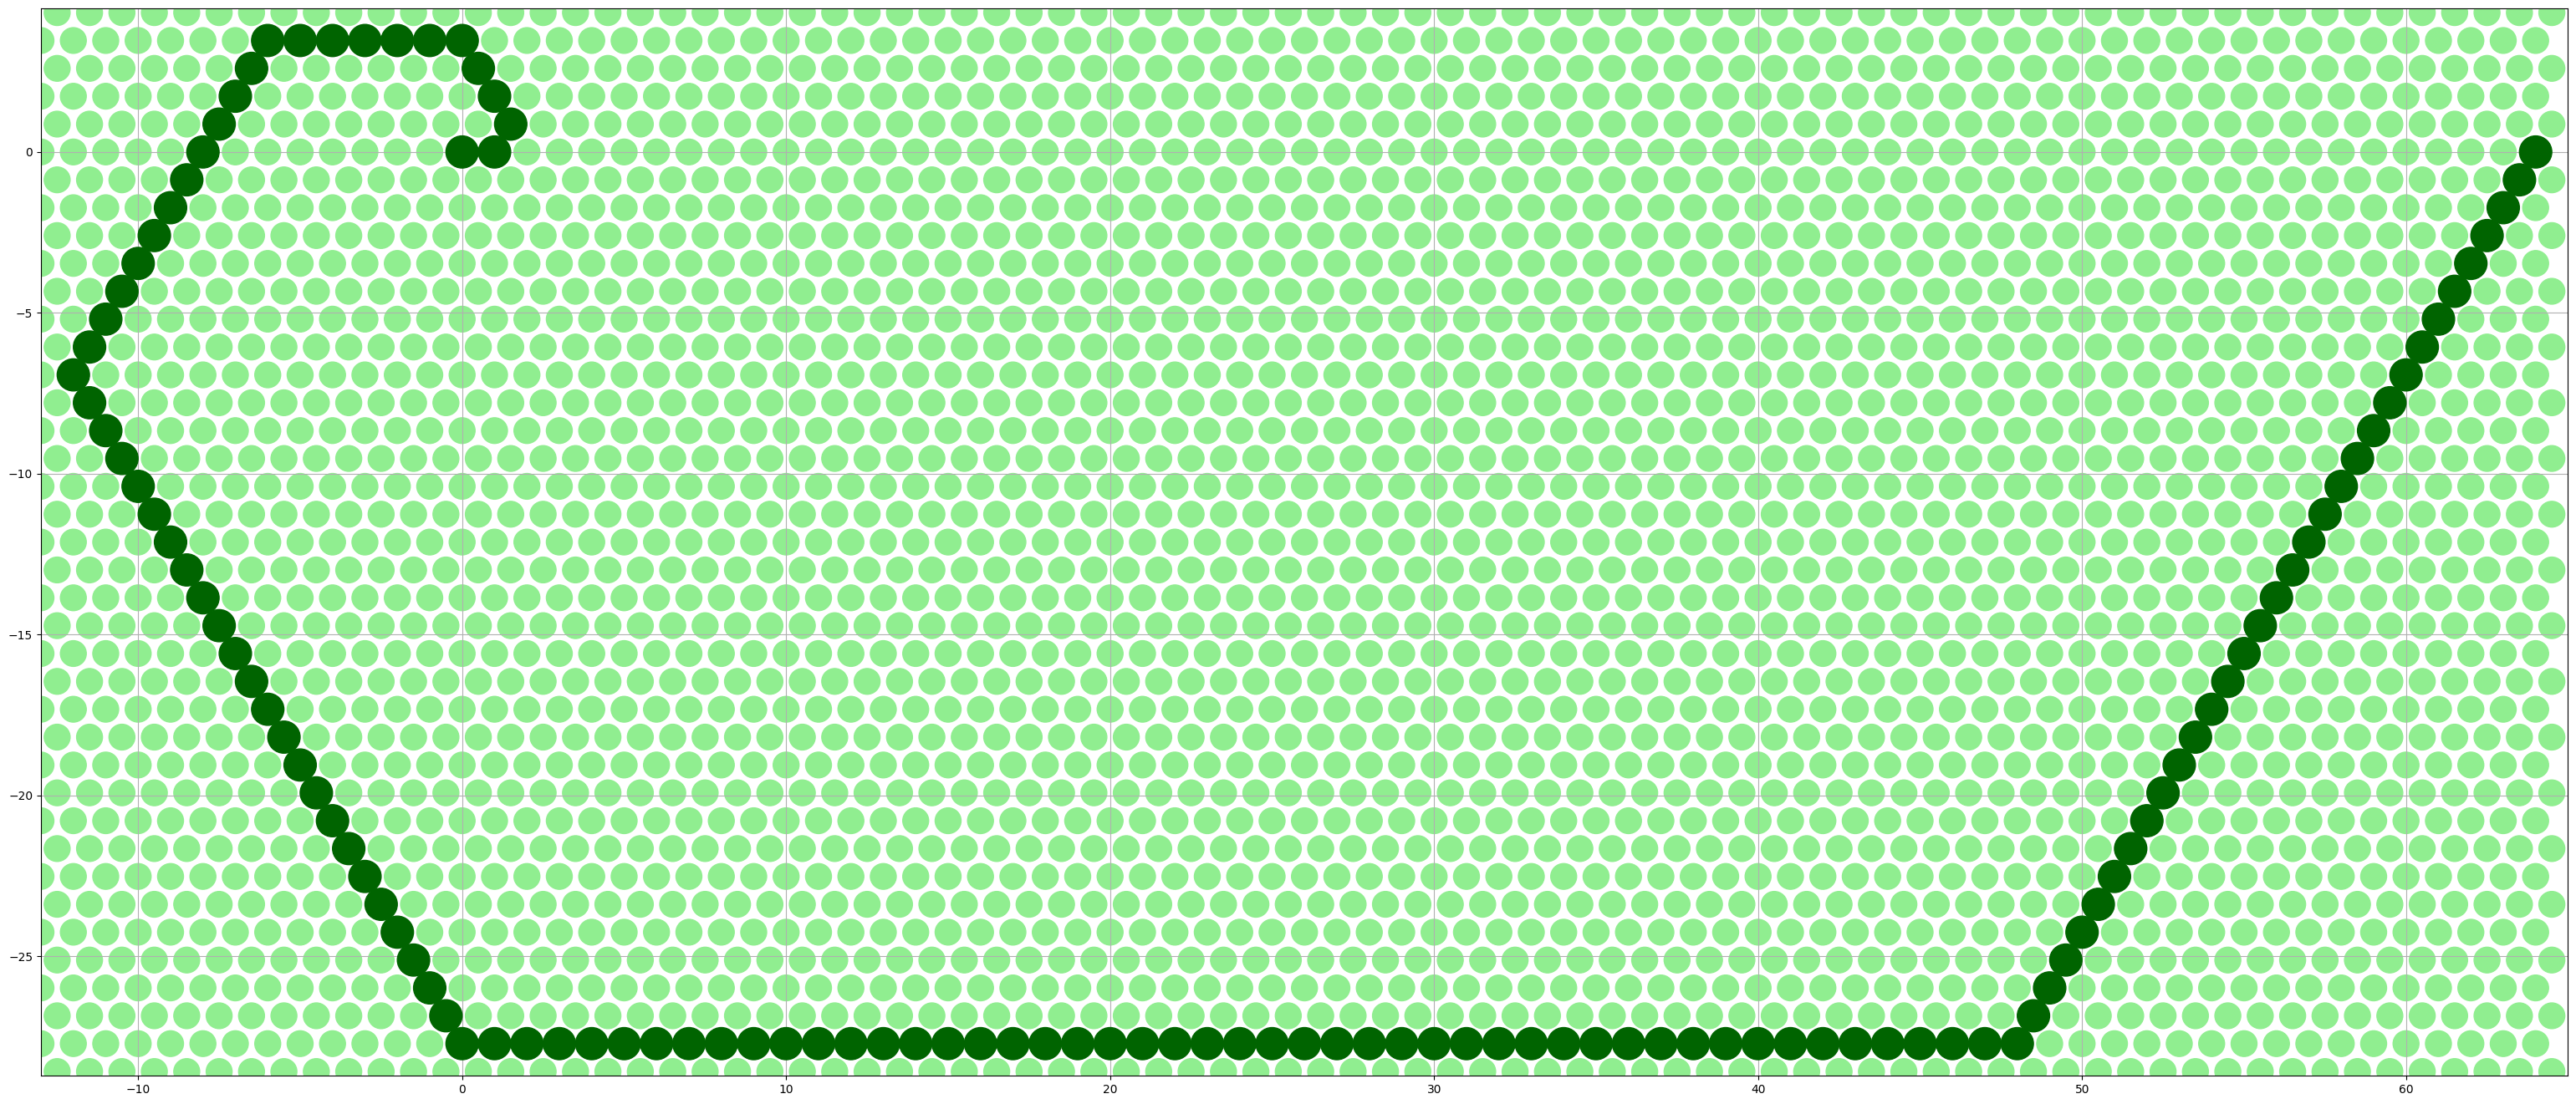

In [142]:
max_r, min_r, max_c, min_c = -1, 1, -1, 1
min_x, max_x, min_y, max_y = 1, -1, 1, -1
for cell in Frankies_path:
    max_r = max(max_r, cell.r)
    min_r = min(min_r, cell.r)
    max_c = max(max_c, cell.c)
    min_c = min(min_c, cell.c)  
    x, y = cell.xy()
    max_x = max(max_x, x)
    min_x = min(min_x, x)
    max_y = max(max_y, y)
    min_y = min(min_y, y)
    

bg_centers = []
for a in [0,1]:
    for r in range(min_r-1, max_r+1):
        for c in range(min_c-1, max_c+1):
            bg_centers.append( hecs(a,r,c) )

from matplotlib import pyplot as plt
from matplotlib.patches import Circle

fig, ax = plt.subplots( figsize=((max_x - min_x + 2)/2, (max_y - min_y + 2)/2) )
for cell in bg_centers:
    x, y = cell.xy()
    # draw a circle at (x,y) with radius 0.4
    circle = Circle((x, y), 0.4, color='lightgreen', fill=True, zorder=1)
    ax.add_patch(circle)

for cell in Frankies_path:
    x, y = cell.xy()
    circle = Circle((x, y), 0.5, color='darkgreen', fill=True, zorder=2)
    ax.add_patch(circle)

#ax.set_facecolor("lightblue")

plt.xlim(min_x - 1, max_x + 1)
plt.ylim(min_y - 1, max_y + 1)
plt.grid(True)
plt.show()

Looks like the answer to the fiddler is 64.

With 64 distance, 128 steps, there seems to be a lot of powers of 2 here, but I am not sure if there is a more direct way to reach the answer.

Visually, it looks like the direction switchover points are +/-30 degrees, +/-150 degrees and +/- 90 degrees.

# Extra Credit Solution

In [ ]:
from fractions import Fraction as F

timestamp = 0
food_map = {}
food_map[ (0,0,0) ] = F(1,1)

while True:    
    if (0,0,0) in food_map:
        print (f"Timestamp {timestamp} : {float(food_map[(0,0,0)]):.6f} : {food_map[(0,0,0)]}")
        if food_map[(0,0,0)] < F(1,100):
            break

    new_food_map = {}
    for (a,r,c), food in food_map.items():
        cell = hecs(a,r,c)
        neighbors = cell.neighbors()
        distributed_food = food / 6
        for neighbor in neighbors:
            key = neighbor.arc()
            if key in new_food_map:
                new_food_map[key] += distributed_food
            else:
                new_food_map[key] = distributed_food
    
    food_map = new_food_map
    timestamp += 1
    

Timestamp 0 : 1.000000 : 1
Timestamp 2 : 0.166667 : 1/6
Timestamp 3 : 0.055556 : 1/18
Timestamp 4 : 0.069444 : 5/72
Timestamp 5 : 0.046296 : 5/108
Timestamp 6 : 0.043724 : 85/1944
Timestamp 7 : 0.036008 : 35/972
Timestamp 8 : 0.032632 : 1015/31104
Timestamp 9 : 0.028840 : 6055/209952
Timestamp 10 : 0.026269 : 14707/559872
Timestamp 11 : 0.023915 : 120505/5038848
Timestamp 12 : 0.022041 : 333179/15116544
Timestamp 13 : 0.020395 : 77077/3779136
Timestamp 14 : 0.018999 : 861575/45349632
Timestamp 15 : 0.017771 : 3626623/204073344
Timestamp 16 : 0.016697 : 872303575/52242776064
Timestamp 17 : 0.015743 : 11423269/725594112
Timestamp 18 : 0.014894 : 126049117337/8463329722368
Timestamp 19 : 0.014130 : 39863185505/2821109907456
Timestamp 20 : 0.013442 : 1365136910995/101559956668416
Timestamp 21 : 0.012817 : 216947654495/16926659444736
Timestamp 22 : 0.012248 : 414624859285/33853318889472
Timestamp 23 : 0.011727 : 148871996845/12694994583552
Timestamp 24 : 0.011248 : 41126150248495/3656158440

# Conclusion

Fiddler Answer = 64

Extra Credit Answer = 28